In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle
from PIL import Image
import pydicom
import SimpleITK as sitk

from medpy.filter.smoothing import anisotropic_diffusion
from scipy.ndimage import median_filter
from skimage import measure, morphology
import scipy.ndimage as ndimage
from sklearn.cluster import KMeans

In [2]:
def load_npy(file_path: str):
    return np.load(file_path)

def load_npz(file_path: str):
    data = np.load(file_path)
    return data

def load_pickle(file_path: str):
    with open(file_path, "rb") as f:
        data = pickle.load(f) 
    return data

def load_dcom(file_path: str):
    return pydicom.dcmread(file_path)

def scale_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image, dtype=np.uint8)
    
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    
    return scaled_image.astype(np.uint8)

def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val > 0:
        image = (image - min_val) / (max_val - min_val)

    return image

def lung_window_clip(array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = array.copy()
    clipped_array[clipped_array > max_px] = max_px
    clipped_array[clipped_array < min_px] = min_px
    return clipped_array

def plot_images(array_HU, array_Lung, title1="HU", title2="Lung"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(array_HU, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis("off")  # Hide axis

    axes[1].imshow(array_Lung, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis("off")  # Hide axis

def numpy_to_gif(image_array, mask_array, lung_array, folder_path="/data/hpc/dqm/3D-SegClass-Medical/assets", folder_name: str = "image", case_name: str = "3", duration=100):
    folder_path = folder_path + "/" + folder_name
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path, exist_ok=True)
        
    save_path_x = f"{folder_path}/{case_name}.gif"

    print(save_path_x)
    frames = []
    
    for i in range(image_array.shape[0]):
        img = Image.fromarray(scale_image(image_array[i, :, :]))
        lung = Image.fromarray(scale_image(lung_array[i, :, :]))
        mask = Image.fromarray(scale_image(mask_array[i, :, :]))
        
        combined = Image.new("L", (img.width * 3, img.height))
        combined.paste(img, (0, 0))
        combined.paste(mask, (mask.width, 0))
        combined.paste(lung, (lung.width * 2, 0))
        
        frames.append(combined)
        
    frames[0].save(save_path_x, save_all=True, append_images=frames[1:], duration=duration, loop=0)

def lung_window_clip_volume(pixel_array: np.ndarray, min_px: int = -1200, max_px: int = 800):
    clipped_array = []
    for arr in pixel_array:
        clipped = arr.copy()
        clipped[clipped > max_px] = max_px
        clipped[clipped < min_px] = min_px
        clipped_array.append(clipped)
        
    return np.stack(clipped_array, axis = 0)


In [3]:
lst = [f"{i:04d}" for i in range(1, 1013)]

In [7]:
for case in lst:
    if int(case) < 712:
        continue
    try:
        image = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-{case}/{case}_NI001.npy")
        lung = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Lung_Segmentation_v2/LIDC-IDRI-{case}/{case}_NI001.npy")
        mask = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-{case}/{case}_MA001.npy")
    except Exception:
        image = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Clean/Image/LIDC-IDRI-{case}/{case}_CN001.npy")
        lung = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Lung_Segmentation_v2/LIDC-IDRI-{case}/{case}_CN001.npy")
        mask = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Clean/Mask/LIDC-IDRI-{case}/{case}_CM001.npy")

    numpy_to_gif(image, mask * 255, lung, case_name=f"{case}", folder_name="all")

/data/hpc/dqm/3D-SegClass-Medical/assets/all/0712.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0713.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0714.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0715.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0716.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0717.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0718.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0719.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0720.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0721.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0722.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0723.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0724.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0725.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0726.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0727.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0728.gif
/data/hpc/dqm/3D-SegClass-Medical/assets/all/0729.gif
/data/hpc/dqm/3D-SegClass-Me

In [ ]:
case = "0850"
image = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-{case}/{case}_NI001.npy")
lung = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Lung_Segmentation_v2/LIDC-IDRI-{case}/{case}_NI001.npy")
mask = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-{case}/{case}_MA001.npy")

print(image.shape)
print(lung.shape)
print(mask.shape)

numpy_to_gif(image, mask * 255, lung, case_name=f"{case}_v3", folder_name="vis")

(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/vis/0850_v3.gif


In [10]:
lung.min()

-1.1546316

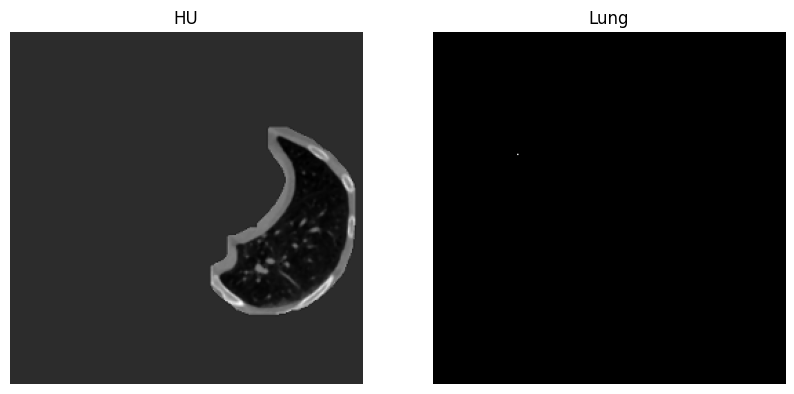

In [6]:
plot_images(lung[50, :, :], mask[90, :, :] * 255)

In [61]:
def largest_label_volume(im, bg=-1):
    vals, counts = np.unique(im, return_counts=True)

    counts = counts[vals != bg]
    vals = vals[vals != bg]

    if len(counts) > 0:
        return vals[np.argmax(counts)]
    else:
        return None
    
def denormalize_clipped(image, MIN_BOUND=-1000.0, MAX_BOUND=400.0):
    image = image * (MAX_BOUND - MIN_BOUND) + MIN_BOUND
    return image

def segment_lung_mask(image, fill_lung_structures=True): # include structures within the lung
    
    # not actually binary, but 1 and 2. 
    # 0 is treated as background, which we do not want
    binary_image = np.array(image > -320, dtype=np.int8)+1
    labels = measure.label(binary_image)

    background_label = labels[0,0,0]
    
    #Fill the air around the person
    binary_image[background_label == labels] = 2
    
    # Method of filling the lung structures (that is superior to something like 
    # morphological closing)
    if fill_lung_structures:
        # For every slice we determine the largest solid structure
        for i, axial_slice in enumerate(binary_image):
            axial_slice = axial_slice - 1
            labeling = measure.label(axial_slice)
            l_max = largest_label_volume(labeling, bg=0)
            
            if l_max is not None: #This slice contains some lung
                binary_image[i][labeling != l_max] = 1
    
    binary_image -= 1 #Make the image actual binary
    binary_image = 1-binary_image # Invert it, lungs are now 1
    
    # Remove other air pockets insided body
    labels = measure.label(binary_image, background=0)
    l_max = largest_label_volume(labels, bg=0)
    if l_max is not None: # There are air pockets
        binary_image[labels != l_max] = 0
 
    return binary_image.astype(np.float32)

In [22]:
def make_lungmask_version_2(img):
    
    image_original = img.copy()
    
    row_size = img.shape[0]
    col_size = img.shape[1]

    mean = np.mean(img)
    std = np.std(img)
    img = img - mean
    img = img / std
    
    # Find the average pixel value near the lungs
    # to renormalize washed out images
    middle = img[int(col_size / 5):int(col_size / 5 * 4), int(row_size / 5):int(row_size / 5 * 4)]
    mean = np.mean(middle)
    max = np.max(img)
    min = np.min(img)
    # To improve threshold finding, I'm moving the
    # underflow and overflow on the pixel spectrum
    img[img == max] = mean
    img[img == min] = mean
    
    # apply median filter
    img = median_filter(img,size=3)
    #apply anistropic non-linear diffusion filter- This removes noise without blurring the nodule boundary
    img = anisotropic_diffusion(img)
    #
    # Using Kmeans to separate foreground (soft tissue / bone) and background (lung/air)
    #
    # kmeans = KMeans(n_clusters=2).fit(np.reshape(middle, [np.prod(middle.shape), 1]))
    # centers = sorted(kmeans.cluster_centers_.flatten())
    # threshold = np.mean(centers)
    # thresh_img = np.where(img < threshold, 1.0, 0.0)  # threshold the image
    
    thresh_img = segment_lung_mask(image_original)
    plt.imshow(thresh_img)

    # First erode away the finer elements, then dilate to include some of the pixels surrounding the lung.
    # We don't want to accidentally clip the lung.

    eroded = morphology.erosion(thresh_img, np.ones([3, 3]))
    dilation = morphology.dilation(eroded, np.ones([8, 8]))

    labels = measure.label(dilation)  # Different labels are displayed in different colors
    label_vals = np.unique(labels)
    regions = measure.regionprops(labels)
    good_labels = []
    for prop in regions:
        B = prop.bbox
        if B[2] - B[0] < row_size / 10 * 9 and B[3] - B[1] < col_size / 10 * 9 and B[0] > row_size / 5 and B[
            2] < col_size / 5 * 4:
            good_labels.append(prop.label)
    mask = np.ndarray([row_size, col_size], dtype=np.int8)
    mask[:] = 0

    #
    #  After just the lungs are left, we do another large dilation
    #  in order to fill in and out the lung mask
    #
    for N in good_labels:
        mask = mask + np.where(labels == N, 1, 0)
    mask = morphology.dilation(mask, np.ones([10, 10]))  # one last dilation
    
    return mask * img # , mask: Lung Image, Mask

In [40]:
image_denormalized = denormalize_clipped(image)
print(image_denormalized.max())
print(image_denormalized.min())

400.0
-1000.0


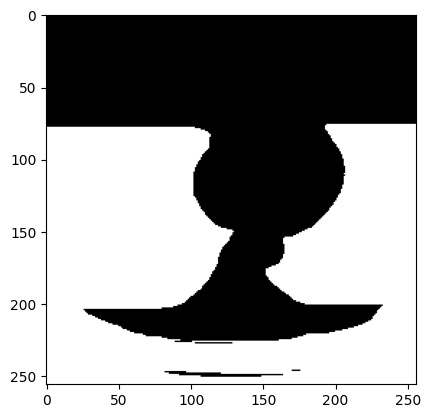

In [28]:
a = segment_lung_mask(image_denormalized)
plt.imshow(a[50, :, :], cmap="gray")

0.0
0.0


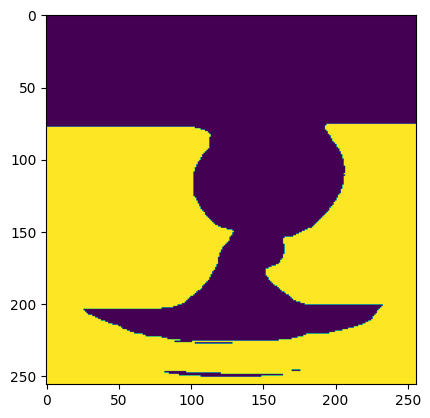

In [27]:
a = make_lungmask_version_2(image_denormalized[50, :, :])
print(a.max())
print(a.min())

In [103]:
test = load_npy("/data/hpc/dqm/3D-SegClass-Medical/assets/test/volume_12_resample.npy")
print(test.shape)
print(test.max())
print(test.min())

(320, 380, 380)
3486
-2449


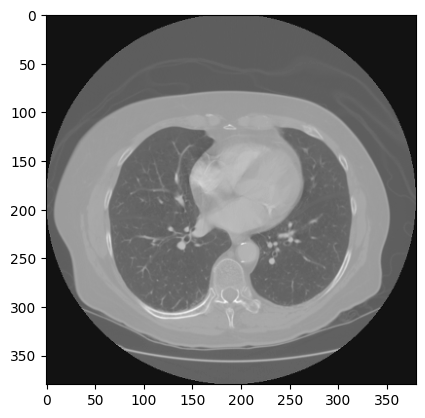

In [105]:
plt.imshow(test[140, :, :], cmap="gray")

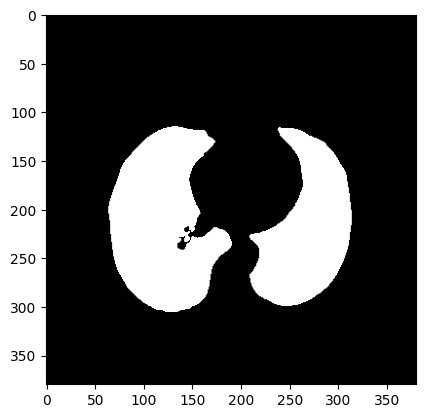

In [106]:
a = segment_lung_mask(test)
plt.imshow(a[140, :, :], cmap="gray")

In [107]:
result = []

for img, thresh_img in zip(test, a):
    row_size = img.shape[0]
    col_size = img.shape[1]

    mean = np.mean(img)
    std = np.std(img)
    img = img - mean
    img = img / std
    
    # Find the average pixel value near the lungs
    # to renormalize washed out images
    middle = img[int(col_size / 5):int(col_size / 5 * 4), int(row_size / 5):int(row_size / 5 * 4)]
    mean = np.mean(middle)
    max = np.max(img)
    min = np.min(img)
    # To improve threshold finding, I'm moving the
    # underflow and overflow on the pixel spectrum
    img[img == max] = mean
    img[img == min] = mean
    
    # apply median filter
    img = median_filter(img,size=3)
    #apply anistropic non-linear diffusion filter- This removes noise without blurring the nodule boundary
    img = anisotropic_diffusion(img)
    
    #
    # Using Kmeans to separate foreground (soft tissue / bone) and background (lung/air)
    #
    # kmeans = KMeans(n_clusters=2).fit(np.reshape(middle, [np.prod(middle.shape), 1]))
    # centers = sorted(kmeans.cluster_centers_.flatten())
    # threshold = np.mean(centers)
    # thresh_img = np.where(img < threshold, 1.0, 0.0)  # threshold the image

    # First erode away the finer elements, then dilate to include some of the pixels surrounding the lung.
    # We don't want to accidentally clip the lung.

    eroded = morphology.erosion(thresh_img, np.ones([3, 3]))
    dilation = morphology.dilation(eroded, np.ones([8, 8]))

    labels = measure.label(dilation)  # Different labels are displayed in different colors
    label_vals = np.unique(labels)
    regions = measure.regionprops(labels)
    good_labels = []
    for prop in regions:
        B = prop.bbox
        if B[2] - B[0] < row_size / 20 * 19 and B[3] - B[1] < col_size / 20 * 19 and B[0] > row_size / 10 and B[
            2] < col_size / 10 * 9:
            good_labels.append(prop.label)
    mask = np.ndarray([row_size, col_size], dtype=np.int8)
    mask[:] = 0

    #
    #  After just the lungs are left, we do another large dilation
    #  in order to fill in and out the lung mask
    #
    for N in good_labels:
        mask = mask + np.where(labels == N, 1, 0)
    mask = morphology.dilation(mask, np.ones([10, 10]))  # one last dilation
    
    result.append(mask * img) # , mask: Lung Image, Mask
print(len(result))

320


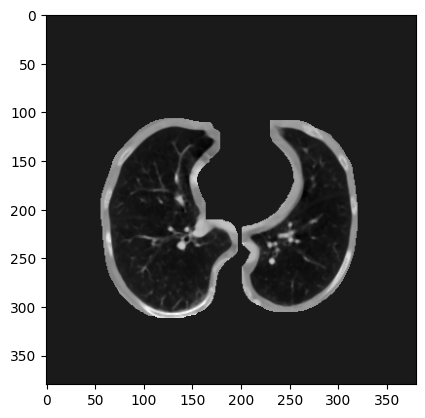

In [109]:
plt.imshow(result[140], cmap="gray")

In [110]:
final = np.stack(result, axis=0)

In [111]:
numpy_to_gif(final, case_name="12_lung_v2_new", folder_name="test")

/data/hpc/dqm/3D-SegClass-Medical/assets/test/12_lung_v2_new_x.gif


In [113]:
test = load_npy("/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-0003/0003_MA001.npy")
print(test.max())
print(test.min())

1
0
